# Implementing a GPT model

Based on Chapter 4 of *<a href="https://github.com/rasbt/LLMs-from-scratch">Build a Large Language Model from Scratch</a>* by Sebastian Raschka

## Quick recap: Chapter 3

We finished the previous chapter by implementing **multi-head self-attention** — the mechanism that lets each token look at (and pull information from) every other token that came before it in the sequence. As a quick refresher, here's what that chapter covered:

- **Self-attention**: for each token, compute a **query**, **key**, and **value** vector. The query of one token is compared (dot product) against the keys of all tokens to get *attention scores*, which are turned into *attention weights* via softmax.
- **Causal masking**: future tokens are masked out (set to $-\infty$ before softmax) so a token can only attend to itself and tokens *before* it — this is what makes the model suitable for left-to-right text generation.
- **Multi-head attention**: rather than computing a single attention pattern, we split the embedding dimension into several smaller "heads," each learning to attend to different kinds of relationships (e.g. one head might track syntax, another might track long-range topic relevance), then concatenate the results back together.

In this notebook we build up a GPT-style language model piece by piece:

1. A placeholder / "dummy" GPT architecture, just to see the overall shape of the model
2. **Layer normalization**, to stabilize training
3. The **GELU** activation and the **feed-forward network**
4. **Shortcut (residual) connections**, so gradients survive in deep networks
5. Wiring self-attention + feed-forward into a single **transformer block**
6. Stacking transformer blocks into the full **GPTModel**
7. A simple `generate_text_simple` function to actually produce text

<p>
    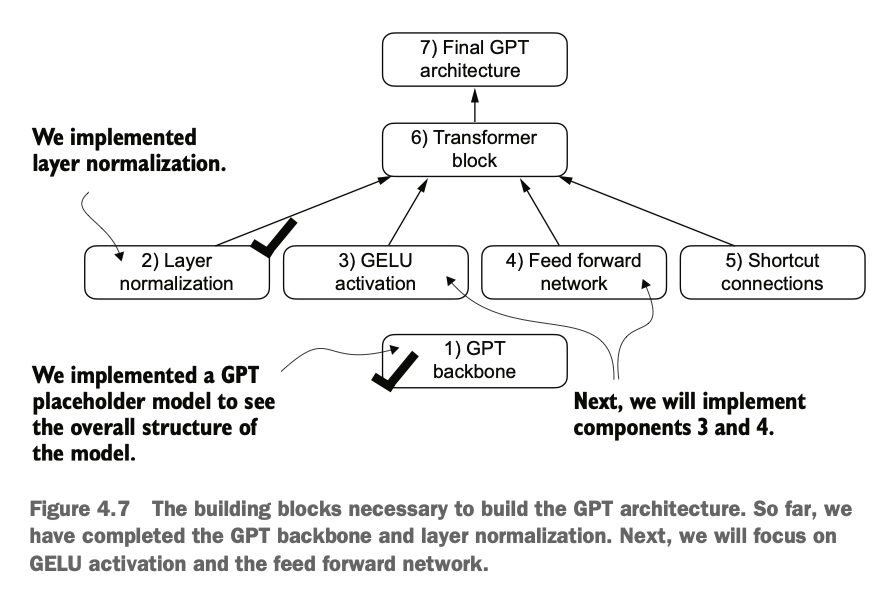
</p>

By the end, we'll have a working (untrained) 124M-parameter GPT-2-sized model implemented purely in PyTorch.

In [21]:
import torch
import torch.nn as nn
import tiktoken
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

matplotlib version: 3.10.8
torch version: 2.4.0
tiktoken version: 0.13.0


## 4.1 Coding an LLM architecture (general structure)

Before building the model, we define a configuration dictionary containing all of its hyperparameters. Keeping these values in one place makes the code easier to read, maintain, and modify.

| Parameter      | Meaning                            |
| -------------- | ---------------------------------- |
| vocab_size     | Number of tokens in vocabulary     |
| context_length | Maximum sequence length            |
| emb_dim        | Embedding dimension                |
| n_heads        | Number of attention heads          |
| n_layers       | Number of transformer blocks       |
| drop_rate      | Dropout probability                |
| qkv_bias       | Whether Q/K/V projections use bias |

In [22]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size (BPE tokenizer used by GPT-2)
    "context_length": 1024, # Context length
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-Key-Value bias
}

#### A placeholder GPT model

Before implementing each component, it's useful to first build the overall structure of the model. This lets us see how data flows from the input tokens to the final output without getting distracted by the details of each layer.
The `DummyTransformerBlock` and `DummyLayerNorm` classes are simple placeholders that return the input unchanged. We'll replace them with fully functional versions as we build the model step by step.

The GPT Architecture:
<div align="center">

```text
Token IDs
    |
    ▼
Token Embeddings
    |
    ▼
Position Embeddings
    |
    ▼
Transformer Blocks (× n_layers)
    |
    ▼
Final LayerNorm
    |
    ▼
Output Projection
    |
    ▼
Vocabulary Logits
```

</div>

In [23]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

To make sure our model is wired together correctly, we'll tokenize two short text examples using GPT-2's tokenizer, combine them into a batch, and pass them through our placeholder model. Since the internal layers don't do any real computation yet, we're simply checking that the data flows through the model and that the input and output shapes are correct.

In [24]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [25]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 Normalizing activations with layer normalization

As neural networks get deeper, the values flowing through the layers can become too large or too small, making training unstable. **Layer normalization** (LayerNorm) helps prevent this by normalizing each input independently so its features have approximately zero mean and unit variance. LayerNorm is applied both before and after the multi-head attention module within the transformer block. Before implementing it, let's look at a simple example to see why it's useful:

In [26]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [27]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


The mean and variance of each row are far from 0 and 1. Let's normalize by hand: subtract the mean, divide by the square root of the variance:
$$
x_{\text{norm}} = \frac{x - \mu}{\sqrt{\sigma^2}}
$$

where:

- $x$ is the original activation value
- $\mu$ is the mean of the activations
- $\sigma^2$ is the variance of the activations

In [28]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


The normalization is applied to each of the two inputs (rows) independently; using dim=-1 applies the calculation across the last dimension (in this case, the feature dimension) instead of the row dimension.

To improve the readability of very small numbers (such as `-5.9605e-08`), we disable scientific notation using `sci_mode=False`:


In [29]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### LayerNorm class

Now let's package this normalization into a reusable `LayerNorm` module. There are two important additions:
- A small constant `eps` is added before taking the square root to prevent division by zero.
- Two trainable parameters, `scale` and `shift`, allow the model to adjust the normalized values if needed during training. They are initialized to 1 and 0, respectively, so the layer initially performs only normalization.

In [30]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [31]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 4.3 mplementing a feed forward network with GELU activations

### A quick overview of activation functions

An activation function is what makes a neural network non-linear — without one, stacking any number of linear layers would still just be one big linear function, no matter how "deep" it looks. A few of the most common ones:

- **Sigmoid**: squashes any input into the range (0, 1). Historically popular, but suffers badly from *vanishing gradients* — for large positive or negative inputs, the curve is nearly flat, so the gradient is close to zero and learning stalls in deep networks.
- **Tanh**: like sigmoid but squashes into (-1, 1) and is zero-centered, which helps a bit, but it still saturates (flattens out) for large inputs and has the same vanishing-gradient issue.
- **ReLU** (Rectified Linear Unit): `max(0, x)`. Simple, cheap, and doesn't saturate for positive inputs, which is why it became the default choice for most deep networks for years. Its weakness is the sharp corner at exactly 0, and the "dying ReLU" problem — a neuron that always outputs 0 for every input in the training set gets a gradient of exactly zero and can stop learning entirely.
- **Leaky ReLU / GELU / SiLU (Swish)**: newer variants designed to fix ReLU's dead-zone problem while keeping most of its benefits. Leaky ReLU allows a small negative slope instead of a hard zero. GELU and SiLU go a step further and make the *entire* curve smooth.

### Why GPT uses GELU

GPT and GPT-2 use GELU instead of ReLU because it's:
- **Smooth everywhere** — no sharp bend at 0, giving more informative gradients through many stacked transformer blocks.
- **Not hard-zeroing negatives** — slightly negative inputs still pass through as small negative values instead of being clipped to exactly 0, so neurons aren't permanently "dead."
- **Probabilistically motivated** — each input is scaled by the probability that a standard normal variable is less than it: large positive → passed through almost unchanged, large negative → pushed near 0, near-zero → smoothly in between. A softer version of ReLU's hard cutoff.


In [32]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

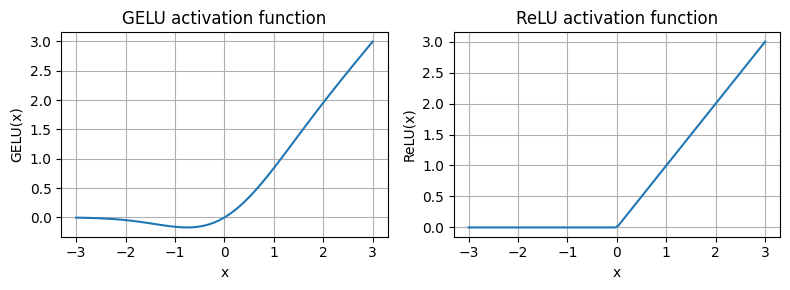

In [33]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

Unlike ReLU, which sets all negative inputs to exactly 0, GELU changes values smoothly and allows small negative outputs. This smooth transition often leads to more stable optimization and improved model performance. <br>
Next, we'll use GELU in the feed-forward network. As in the original Transformer architecture, the network first expands the embedding dimension by a factor of 4, applies the GELU activation, and then projects the activations back to the original embedding dimension.

In [34]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [35]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_tokens, emb_size]
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## 4.4 Adding shortcut connections

As we stack more layers, training becomes more difficult because gradients can become very small as they propagate backward through the network. This is known as **the vanishing gradient problem** and can prevent earlier layers from learning effectively. **Shortcut (or residual) connections** help solve this by adding a layer's input directly to its output, providing a more direct path for gradients during backpropagation:
$$\text{output} = \text{Layer}(x) + x$$

In [36]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

**Without** shortcut connections:

In [37]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152039906941354
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


**With** shortcut connections:

In [39]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


## 4.5 Transformer block

We now have all the core building blocks needed for a GPT model: multi-head self-attention, layer normalization, the feed-forward network with GELU, and residual connections. The next step is to combine them into a **Transformer block** - the fundamental building block that is stacked repeatedly to form the complete GPT architecture. We'll reuse the MultiHeadAttention module that we implemented in Chapter 3.

In [41]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional linear projection

        return context_vec

Now the transformer block itself. The pattern is:

1. Take the input `x`, save it as a shortcut, apply **LayerNorm**, then **multi-head attention**, then dropout, then **add the shortcut back**.
2. Take that result, save it as a new shortcut, apply **LayerNorm** again, then the **feed-forward network**, then dropout, then **add the shortcut back** again.

This is the "pre-norm" transformer design used by GPT-2: layer norm is applied *before* attention/feed-forward, not after.

In [42]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [43]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## 4.6 Coding the GPT model

We can now replace the placeholder pieces from section 4.1 with the real `LayerNorm` and `TransformerBlock` implementations. This gives us the complete `GPTModel`:

1. Token embeddings + positional embeddings, combined and passed through dropout
2. A stack of `n_layers` transformer blocks
3. A final layer norm
4. A linear output head that projects back to vocabulary size (producing logits for the next-token prediction at every position)

In [44]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [45]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


The model hasn't been trained yet, so the logits (and any text generated from them) will still be gibberish.

## 4.7 Generate text

Finally, let's write a simple greedy text-generation loop, `generate_text_simple`. At each step it:

1. Crops the current sequence to at most `context_size` tokens (since the model can't attend beyond its context length)
2. Runs a forward pass to get logits for every position
3. Takes the logits for the *last* position only (the prediction for the next token)
4. Converts those logits to a probability distribution with softmax
5. Picks the single highest-probability token (greedy decoding, via `argmax`)
6. Appends that token to the sequence and repeats

In [46]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is a (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [47]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [48]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [49]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
